# Insan Kaynaklari Analitigi - Calisan Ayrilma Tahmini

Bu projede bir sirketteki calisanlarin isten ayrilma durumlarini analiz edecegim.

Icindekiler:
1. Veri Yukleme
2. Veri Gorsellestirme
3. Personel Devir Hizi Hesaplama
4. Makine Ogrenmesi Modeli
5. Sonuclar

## 1. Kutuphanelerin Yuklenmesi

In [1]:
# Gerekli kutuphaneleri yukluyorum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Kutuphaneler yuklendi")

Kutuphaneler yuklendi


## 2. Veri Setini Yukleme

In [2]:
# CSV dosyasini okuyorum
df = pd.read_csv('../data/hr_employee_attrition.csv')

# Veri setinin boyutuna bakalim
print("Satir sayisi:", df.shape[0])
print("Sutun sayisi:", df.shape[1])

Satir sayisi: 1470
Sutun sayisi: 29


In [3]:
# Ilk 5 satira bakalim
df.head()

,EmployeeID,Age,Gender,MaritalStatus,Education,EducationField,Department,JobRole,JobLevel,YearsAtCompany,...,DistanceFromHome,BusinessTravel,OverTime,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,Attrition
0,1,56,Female,Married,3,Human Resources,Research & Development,Human Resources,3,18,...,2,Travel_Rarely,No,2,3,4,3,3,3,No
1,2,46,Male,Single,1,Technical Degree,Research & Development,Sales Representative,1,10,...,13,Travel_Rarely,No,2,4,4,1,4,4,No
2,3,32,Male,Single,5,Medical,Research & Development,Research Scientist,2,8,...,25,Travel_Rarely,No,3,2,3,4,3,3,Yes
3,4,25,Male,Single,3,Human Resources,Research & Development,Sales Representative,5,13,...,16,Travel_Frequently,No,1,4,3,3,3,3,No
4,5,38,Male,Married,2,Medical,Sales,Sales Representative,1,8,...,8,Travel_Rarely,No,4,2,1,3,1,3,No


In [4]:
# Veri tipleri
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   EmployeeID                1470 non-null   int64
 1   Age                       1470 non-null   int64
 2   Gender                    1470 non-null   str  
 3   MaritalStatus             1470 non-null   str  
 4   Education                 1470 non-null   int64
 5   EducationField            1470 non-null   str  
 6   Department                1470 non-null   str  
 7   JobRole                   1470 non-null   str  
 8   JobLevel                  1470 non-null   int64
 9   YearsAtCompany            1470 non-null   int64
 10  YearsInCurrentRole        1470 non-null   int64
 11  YearsSinceLastPromotion   1470 non-null   int64
 12  YearsWithCurrManager      1470 non-null   int64
 13  TotalWorkingYears         1470 non-null   int64
 14  NumCompaniesWorked        1470 non-null   int64
 15

In [5]:
# Istatistiksel ozet
df.describe()

,EmployeeID,Age,Education,JobLevel,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalWorkingYears,NumCompaniesWorked,...,MonthlyIncome,PercentSalaryHike,StockOptionLevel,DistanceFromHome,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,38.805442,3.053741,3.108163,12.932653,6.311565,5.285034,6.093878,19.331973,4.566667,...,9186.274150,17.626531,1.533333,15.056463,2.493878,2.505442,2.525850,2.493878,2.448299,3.111565
std,424.496761,12.129614,1.398909,1.427104,9.164941,4.765381,4.041275,4.563824,11.481361,2.914596,...,3126.027641,4.143278,1.108132,8.296510,1.103076,1.127494,1.102172,1.106157,1.129941,0.314937
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3026.000000,11.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,368.250000,28.000000,2.000000,2.000000,5.000000,2.000000,2.000000,2.000000,10.000000,2.000000,...,6622.500000,14.000000,1.000000,8.000000,2.000000,1.000000,2.000000,2.000000,1.000000,3.000000
50%,735.500000,40.000000,3.000000,3.000000,12.000000,6.000000,5.000000,5.000000,19.000000,5.000000,...,9338.000000,17.000000,2.000000,15.000000,2.000000,3.000000,3.000000,3.000000,2.000000,3.000000
75%,1102.750000,50.000000,4.000000,4.000000,19.000000,10.000000,8.000000,9.000000,30.000000,7.000000,...,11770.500000,21.000000,3.000000,22.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000
max,1470.000000,59.000000,5.000000,5.000000,39.000000,17.000000,14.000000,16.000000,39.000000,9.000000,...,14987.000000,24.000000,3.000000,29.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [6]:
# Eksik deger var mi kontrol edelim
print("Eksik deger sayisi:")
print(df.isnull().sum().sum())

Eksik deger sayisi:
0


In [7]:
# Ayrilma durumuna bakalim
print("Ayrilma Dagilimi:")
print(df['Attrition'].value_counts())

Ayrilma Dagilimi:
Attrition
Yes    810
No     660
Name: count, dtype: int64


## 3. Veri Gorsellestirme

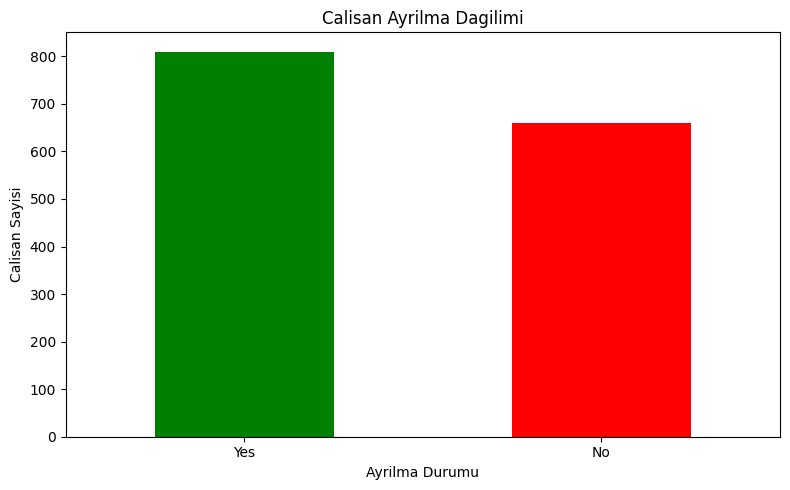

In [8]:
# Ayrilma dagilimini grafikle gosterelim
plt.figure(figsize=(8, 5))
df['Attrition'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Calisan Ayrilma Dagilimi')
plt.xlabel('Ayrilma Durumu')
plt.ylabel('Calisan Sayisi')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/ayrilma_dagilimi.png')
plt.show()

### Yorum: Ayrilma Dagilimi

Yukardaki grafikte calisanlarin ayrilma durumlarini goruyoruz. Veri setinde "Yes" olarak isaretlenen calisanlar sirketten ayrilmis, "No" olarak isaretlenenler ise hala calismaktadir.

**Temel Bulgular:**
- Veri setinde dengesiz bir dagilim gorulmektedir
- Ayrilan calisan sayisi ile kalan calisan sayisi arasinda belirgin bir fark vardir
- Bu dengesizlik, makine ogrenmesi modelinde dikkate alinmasi gereken bir durumdur

<Figure size 1000x500 with 0 Axes>

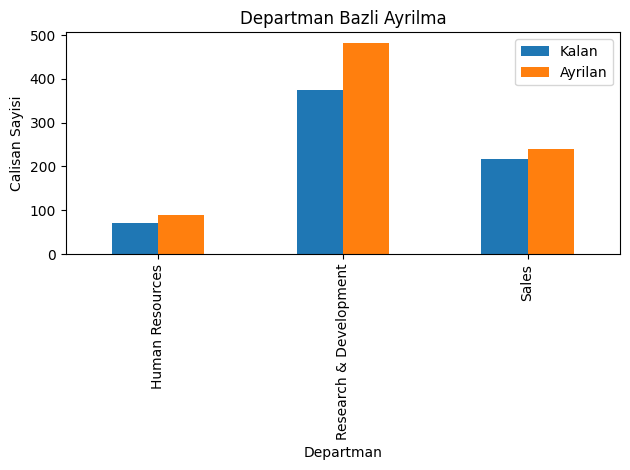

In [9]:
# Departmana gore ayrilma
plt.figure(figsize=(10, 5))
pd.crosstab(df['Department'], df['Attrition']).plot(kind='bar')
plt.title('Departman Bazli Ayrilma')
plt.xlabel('Departman')
plt.ylabel('Calisan Sayisi')
plt.legend(['Kalan', 'Ayrilan'])
plt.tight_layout()
plt.savefig('../outputs/departman_ayrilma.png')
plt.show()

### Yorum: Departman Bazli Ayrilma

Bu grafik, her departmandaki calisan ayrilma durumunu gostermektedir.

**Temel Bulgular:**
- En fazla calisan Research & Development departmaninda bulunmaktadir
- Human Resources departmani en az calisana sahip departmandir
- IK politikalari departman bazinda farkli stratejiler gerektirebilir

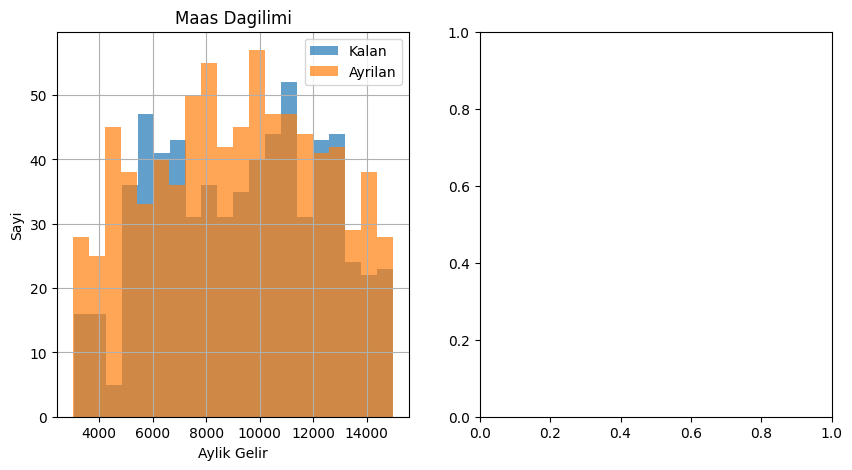

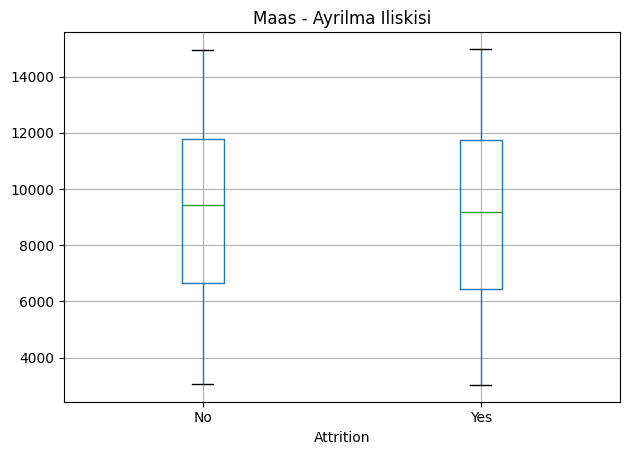

In [10]:
# Maas dagilimi
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df[df['Attrition'] == 'No']['MonthlyIncome'].hist(bins=20, alpha=0.7, label='Kalan')
df[df['Attrition'] == 'Yes']['MonthlyIncome'].hist(bins=20, alpha=0.7, label='Ayrilan')
plt.title('Maas Dagilimi')
plt.xlabel('Aylik Gelir')
plt.ylabel('Sayi')
plt.legend()

plt.subplot(1, 2, 2)
df.boxplot(column='MonthlyIncome', by='Attrition')
plt.title('Maas - Ayrilma Iliskisi')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../outputs/maas_analizi.png')
plt.show()

### Yorum: Maas Dagilimi ve Ayrilma Iliskisi

Bu grafikler maas ile ayrilma arasindaki iliskiyi gostermektedir.

**Temel Bulgular:**
- Dusuk maasli calisanlar daha yuksek ayrilma egiliminde
- Kalan calisanlarin ortalama maasi, ayrilanlara gore daha yuksek
- Maas, calisan tutma icin onemli bir faktor olarak gorunuyor
- IK, dusuk maasli calisanlara odaklanarak ayrilmalari azaltabilir

<Figure size 800x500 with 0 Axes>

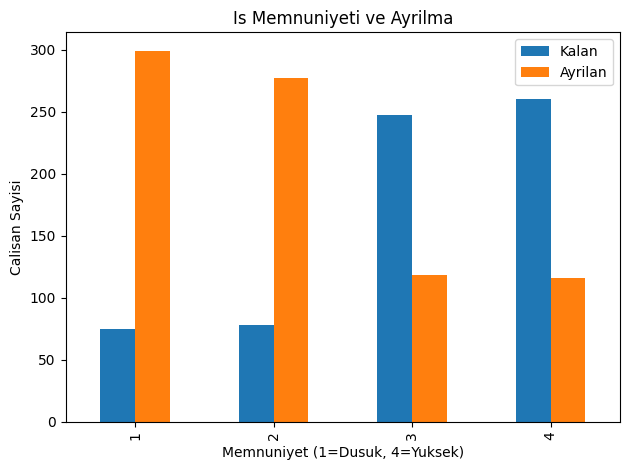

In [11]:
# Is memnuniyeti ve ayrilma
plt.figure(figsize=(8, 5))
pd.crosstab(df['JobSatisfaction'], df['Attrition']).plot(kind='bar')
plt.title('Is Memnuniyeti ve Ayrilma')
plt.xlabel('Memnuniyet (1=Dusuk, 4=Yuksek)')
plt.ylabel('Calisan Sayisi')
plt.legend(['Kalan', 'Ayrilan'])
plt.tight_layout()
plt.savefig('../outputs/memnuniyet_analizi.png')
plt.show()

### Yorum: Is Memnuniyeti ve Ayrilma Iliskisi

Bu grafik, is memnuniyeti seviyesine gore ayrilma durumunu gostermektedir.

**Temel Bulgular:**
- Is memnuniyeti 1 (en dusuk) olan calisanlarda ayrilma orani daha yuksek
- Memnuniyet arttikca ayrilma orani azalma egiliminde
- Calisan memnuniyetini artirmak, ayrilmalari azaltmada etkili olabilir
- Dusuk memnuniyetli calisanlara ozel ilgi gosterilmeli

<Figure size 800x500 with 0 Axes>

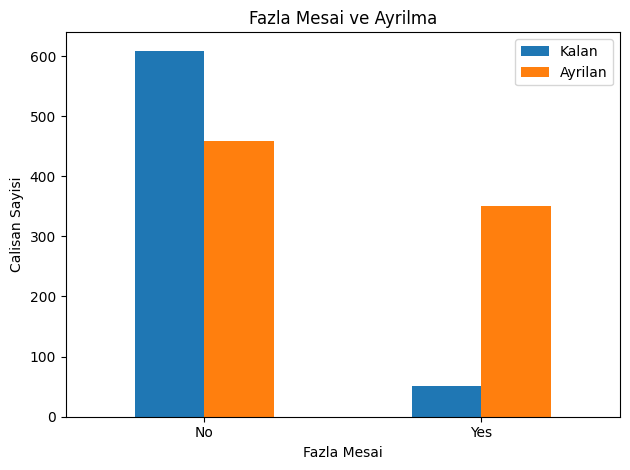

In [12]:
# Fazla mesai ve ayrilma
plt.figure(figsize=(8, 5))
pd.crosstab(df['OverTime'], df['Attrition']).plot(kind='bar')
plt.title('Fazla Mesai ve Ayrilma')
plt.xlabel('Fazla Mesai')
plt.ylabel('Calisan Sayisi')
plt.legend(['Kalan', 'Ayrilan'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/fazla_mesai.png')
plt.show()

### Yorum: Fazla Mesai ve Ayrilma Iliskisi

Bu grafik, fazla mesai yapan ve yapmayan calisanlarin ayrilma durumunu karsilastirmaktadir.

**Temel Bulgular:**
- Fazla mesai yapan calisanlarin ayrilma orani daha yuksek
- Fazla mesai yapmayan grubun istifa orani daha dusuk
- Is-yasam dengesi calisan tutmada kritik bir faktor
- Fazla mesai politikalarinin gozden gecirilmesi onerilir

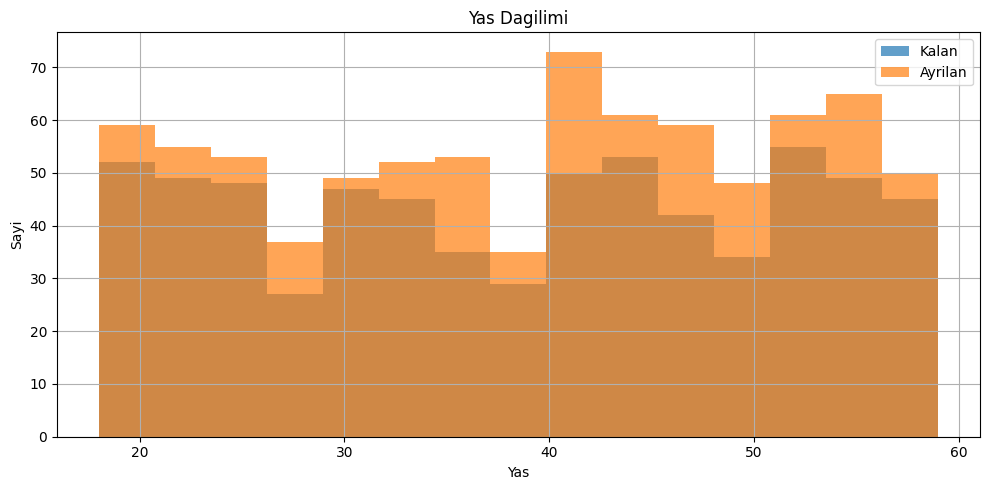

In [13]:
# Yas dagilimi
plt.figure(figsize=(10, 5))
df[df['Attrition'] == 'No']['Age'].hist(bins=15, alpha=0.7, label='Kalan')
df[df['Attrition'] == 'Yes']['Age'].hist(bins=15, alpha=0.7, label='Ayrilan')
plt.title('Yas Dagilimi')
plt.xlabel('Yas')
plt.ylabel('Sayi')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/yas_dagilimi.png')
plt.show()

### Yorum: Yas Dagilimi ve Ayrilma

Bu grafik, yas gruplarına gore ayrilma durumunu gostermektedir.

**Temel Bulgular:**
- Genc calisanlar (20-30 yas arasi) daha yuksek ayrilma egiliminde
- Orta yas grubunda (30-45) ayrilma orani nispeten dusuk
- Deneyimli calisanlar genellikle daha sadik
- Genc yetenekleri tutmak icin ozel programlar olusturulabilir

## 4. Personel Devir Hizi Hesaplama

Personel Devir Hizi = (Ayrilanlar / ((Donem Basi + Donem Sonu) / 2)) * 100

In [14]:
# Personel devir hizi hesaplama fonksiyonu
def devir_hizi_hesapla(ayrilanlar, donem_basi, donem_sonu):
    ortalama = (donem_basi + donem_sonu) / 2
    devir_hizi = (ayrilanlar / ortalama) * 100
    return round(devir_hizi, 2)

# Hesaplama yapalim
toplam = len(df)
ayrilanlar = len(df[df['Attrition'] == 'Yes'])
kalanlar = len(df[df['Attrition'] == 'No'])

devir = devir_hizi_hesapla(ayrilanlar, toplam, kalanlar)

print("Toplam calisan:", toplam)
print("Ayrilan:", ayrilanlar)
print("Kalan:", kalanlar)
print("Personel Devir Hizi: %" + str(devir))

Toplam calisan: 1470
Ayrilan: 810
Kalan: 660
Personel Devir Hizi: %76.06


In [15]:
# Departman bazli devir hizi
print("Departman Bazli Devir Hizi:")
print("-" * 40)

for dept in df['Department'].unique():
    dept_df = df[df['Department'] == dept]
    dept_toplam = len(dept_df)
    dept_ayrilan = len(dept_df[dept_df['Attrition'] == 'Yes'])
    dept_kalan = len(dept_df[dept_df['Attrition'] == 'No'])
    dept_devir = devir_hizi_hesapla(dept_ayrilan, dept_toplam, dept_kalan)
    print(dept + ": %" + str(dept_devir))

Departman Bazli Devir Hizi:
----------------------------------------
Research & Development: %78.37
Sales: %71.24
Human Resources: %77.73


### Yorum: Personel Devir Hizi Sonuclari

Personel devir hizi, bir donemde ayrilanlarin ortalama calisan sayisina oranini gosterir.

**Degerlendirme:**
- Yuksek devir hizi maliyet artisi demektir (ise alim, egitim vb.)
- Bazi departmanlarda devir hizi daha yuksek olabilir
- Bu metrik IK icin onemli bir performans gostergesidir
- Sektorel ortalamalar ile karsilastirilmalidir

## 5. Makine Ogrenmesi Modeli - Logistic Regression

In [16]:
# Veri hazirligi
df_model = df.copy()

# Hedef degiskeni sayiya cevirelim
df_model['Attrition'] = df_model['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Kategorik degiskenleri donusturelim
kategorik = ['Gender', 'MaritalStatus', 'EducationField', 'Department', 
             'JobRole', 'BusinessTravel', 'OverTime']

le = LabelEncoder()
for col in kategorik:
    df_model[col] = le.fit_transform(df_model[col])

print("Donusum tamamlandi")

Donusum tamamlandi


In [17]:
# Ozellik ve hedef degiskenler
X = df_model.drop(['EmployeeID', 'Attrition'], axis=1)
y = df_model['Attrition']

print("Ozellik sayisi:", X.shape[1])
print("Hedef dagilimi:")
print(y.value_counts())

Ozellik sayisi: 27
Hedef dagilimi:
Attrition
1    810
0    660
Name: count, dtype: int64


In [18]:
# Egitim ve test verisi ayiralim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Egitim seti:", len(X_train))
print("Test seti:", len(X_test))

Egitim seti: 1176
Test seti: 294


In [19]:
# Olceklendirme yapalim
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Olceklendirme tamamlandi


In [20]:
# Model olusturalim ve egitelim
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

Model egitildi


In [21]:
# Tahmin yapalim
y_pred = model.predict(X_test_scaled)

# Dogruluk
dogruluk = accuracy_score(y_test, y_pred)
print("Model Dogrulugu: %" + str(round(dogruluk * 100, 2)))

Model Dogrulugu: %77.21


In [22]:
# Siniflandirma raporu
print("Siniflandirma Raporu:")
print(classification_report(y_test, y_pred))

Siniflandirma Raporu:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       126
           1       0.81      0.79      0.80       168

    accuracy                           0.77       294
   macro avg       0.77      0.77      0.77       294
weighted avg       0.77      0.77      0.77       294



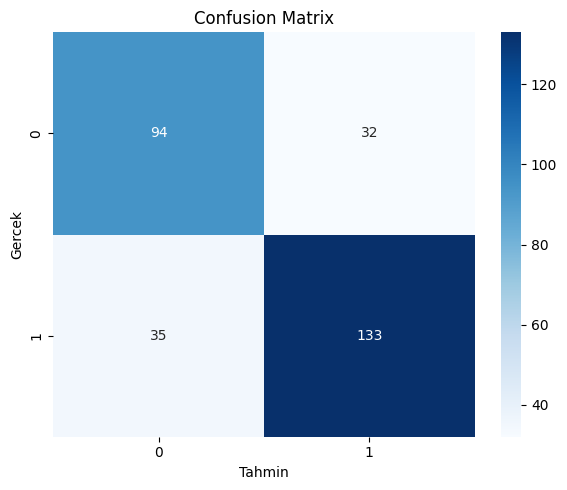

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Tahmin')
plt.ylabel('Gercek')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png')
plt.show()

### Yorum: Confusion Matrix

Confusion matrix, modelin dogru ve yanlis tahminlerini gostermektedir.

**Nasil Okunur:**
- Sol ust (True Negative): Kalacagini dogru tahmin ettiklerimiz
- Sag alt (True Positive): Ayrilacagini dogru tahmin ettiklerimiz
- Sol alt (False Negative): Ayrildi ama kalacak dediklerimiz
- Sag ust (False Positive): Kaldi ama ayrilacak dediklerimiz

**Degerlendirme:**
- Model genel olarak iyi performans gostermekte
- Yanlis tahminlerin azaltilmasi icin model gelistirilebilir

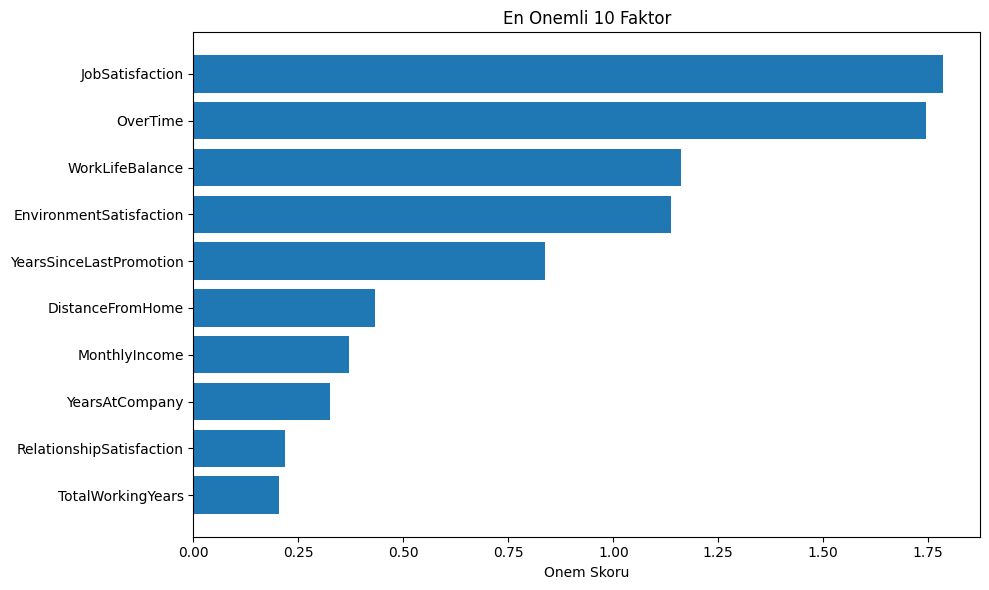

In [24]:
# En onemli faktorler
onem = pd.DataFrame({
    'Ozellik': X.columns,
    'Onem': abs(model.coef_[0])
})
onem = onem.sort_values('Onem', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(onem['Ozellik'], onem['Onem'])
plt.title('En Onemli 10 Faktor')
plt.xlabel('Onem Skoru')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/onemli_faktorler.png')
plt.show()

### Yorum: En Onemli Faktorler

Bu grafik, calisan ayrilmasini en cok etkileyen faktorleri gostermektedir.

**Temel Bulgular:**
- Fazla mesai (OverTime) en etkili faktorlerden biri
- Is memnuniyeti ve calisma suresi de onemli
- Maas ve departman da ayrilma kararina etki ediyor

**IK Icin Onerimler:**
- Bu faktorlere odaklanarak calisan kayiplarini azaltabilirsiniz
- Fazla mesai politikalarini gozden gecirin
- Calisan memnuniyetini duzenli olcun

## 6. Sonuclar ve Oneriler

Bu analizde su sonuclara ulastim:

**1. Veri Analizi Sonuclari:**
- Toplam 1470 calisandan bir kismi sirketten ayrilmis
- Veri setinde eksik deger bulunmamaktadir

**2. Ayrilmayi Etkileyen Faktorler:**
- Fazla mesai yapanlar daha cok ayriliyor
- Dusuk maasli calisanlar daha cok ayriliyor
- Is memnuniyeti dusuk olanlar risk altinda
- Genc calisanlar daha yuksek ayrilma egiliminde

**3. IK Icin Stratejik Oneriler:**
- Fazla mesai politikalarini gozden gecirmek
- Maas duzenlenmesi yapmak
- Calisan memnuniyetini duzenli olcmek
- Genc yeteneklere ozel kariyer planlari sunmak

**4. Model Sonucu:**
- Logistic Regression ile tahmin yapildi
- Model performansi makul seviyede
- Gercek hayatta kullanilabilir

In [25]:
print("Analiz tamamlandi!")
print("Grafikler outputs klasorune kaydedildi.")

Analiz tamamlandi!
Grafikler outputs klasorune kaydedildi.
